In [1]:
from astropy.io import fits

hdul = fits.open("/kaggle/input/datasets/rajarshi2712/astroml/xmm_gaiadr3_xmatch_new_poserr_cluster_0_0.fits")
# print(hdul[1].columns)

In [2]:
label_cols = [
    "proba_xg",      # probability that Gaia is correct counterpart
    "proba_x_g",     # probability no Gaia counterpart exists
    "nPos"
]

positional_cols = [
    "dMEC",
    "chi2Pos",
    "xmm_RA",
    "xmm_DEC",
    "gaia_RA_ICRS",
    "gaia_DE_ICRS",
    "xmm_POSERR",
    "gaia_e_RA_ICRS",
    "gaia_e_DE_ICRS"
]

xmm_cols = [
    "xmm_EP_8_FLUX",
    "xmm_EP_8_FLUX_ERR",
    "xmm_EP_8_RATE",
    "xmm_EP_8_RATE_ERR",
    "xmm_EP_8_DET_ML",
    "xmm_EP_EXTENT",
    "xmm_EP_EXTENT_ML",
    "xmm_EP_HR1",
    "xmm_EP_HR2",
    "xmm_EP_HR3",
    "xmm_EP_HR4"
]

gaia_cols = [
    "gaia_Gmag",
    "gaia_BPmag",
    "gaia_RPmag",
    "gaia_Plx",
    "gaia_pmRA",
    "gaia_pmDE",
    "gaia_chi2AL",
    "gaia_Teff",
    "gaia_logg",
    "gaia_[Fe/H]"
]

## Random Forest Approach

In [3]:
from astropy.io import fits
from astropy.table import Table
import pandas as pd
import numpy as np

# open FITS
hdul = fits.open("/kaggle/input/datasets/rajarshi2712/astroml/xmm_gaiadr3_xmatch_new_poserr_cluster_0_0.fits")

# read using astropy Table
table = Table(hdul[1].data)

# convert to pandas
df = table.to_pandas()

# keep only required columns
label_cols = [
    "proba_xg",
    "proba_x_g",
    "nPos"
]

positional_cols = [
    "dMEC",
    "chi2Pos",
    "xmm_RA",
    "xmm_DEC",
    "gaia_RA_ICRS",
    "gaia_DE_ICRS",
    "xmm_POSERR",
    "gaia_e_RA_ICRS",
    "gaia_e_DE_ICRS"
]

xmm_cols = [
    "xmm_EP_8_FLUX",
    "xmm_EP_8_FLUX_ERR",
    "xmm_EP_8_RATE",
    "xmm_EP_8_RATE_ERR",
    "xmm_EP_8_DET_ML",
    "xmm_EP_EXTENT",
    "xmm_EP_EXTENT_ML",
    "xmm_EP_HR1",
    "xmm_EP_HR2",
    "xmm_EP_HR3",
    "xmm_EP_HR4"
]

gaia_cols = [
    "gaia_Gmag",
    "gaia_BPmag",
    "gaia_RPmag",
    "gaia_Plx",
    "gaia_pmRA",
    "gaia_pmDE",
    "gaia_chi2AL",
    "gaia_Teff",
    "gaia_logg",
    "gaia_[Fe/H]"
]

all_cols = label_cols + positional_cols + xmm_cols + gaia_cols

df = df[all_cols]

# clean infinities
df = df.replace([np.inf, -np.inf], np.nan)

print(df.head())
print("Shape:", df.shape)

   proba_xg  proba_x_g  nPos      dMEC   chi2Pos      xmm_RA    xmm_DEC  \
0  0.950847   0.049153     2  1.309948  3.697350  175.685837  15.479389   
1  0.731852   0.268148     2  2.480992  7.614100  175.685837  15.479389   
2  0.952114   0.047886     2  0.602901  3.642444  175.685837  15.479389   
3  0.930348   0.069652     2  1.410224  4.438089  175.685837  15.479389   
4  0.961685   0.038315     2  1.368589  3.176482  175.685837  15.479389   

   gaia_RA_ICRS  gaia_DE_ICRS  xmm_POSERR  ...  gaia_Gmag  gaia_BPmag  \
0    175.942090     15.430902    0.963438  ...  19.585010   19.772823   
1    175.840862     15.582843    1.271542  ...  20.769823   21.002619   
2    175.595205     15.481550    0.446737  ...  20.759443   20.703943   
3    175.656724     15.243693    0.946684  ...  19.211136   19.388798   
4    175.603401     15.602849    1.085602  ...  21.735395   20.778244   

   gaia_RPmag  gaia_Plx  gaia_pmRA  gaia_pmDE  gaia_chi2AL  gaia_Teff  \
0   19.125206    0.8602      1.536   

In [4]:
# Block 1: Imports
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import rayleigh

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [5]:
# Block 2: Loading data
data_dir = r"/kaggle/input/datasets/rajarshi2712/astroml"
# model_dir = r"C:/Raj_Stuff/Coding/VScode/Workspaces/Astro-ML/Models"

gaia_fits_path = f"{data_dir}/gaiadr3_cluster_0_0.fits"
xmm_fits_path = f"{data_dir}/Unique_SRCID_cluster_0_0_OBSID_all_SRCID.fits"
arches_fits_path = f"{data_dir}/xmm_gaiadr3_xmatch_new_poserr_cluster_0_0.fits"

gaia_tbl = Table.read(gaia_fits_path)
xmm_tbl = Table.read(xmm_fits_path)
arches_tbl = Table.read(arches_fits_path)

gaia_df = gaia_tbl.to_pandas()
xmm_df = xmm_tbl.to_pandas()
arches_df = arches_tbl.to_pandas()

In [6]:
# Block 3: Extracting features
xmm_p1 = xmm_df[["SC_RA", "SC_DEC", "SC_POSERR", "SRCID"]].reset_index(drop=True)
gaia_p1 = gaia_df[["gaia_RA_ICRS", "gaia_DE_ICRS", "gaia_e_RA_ICRS", "gaia_e_DE_ICRS", "gaia_Source"]].reset_index(drop=True)

In [7]:
# # Block 4: Generating pairs
# SEARCH_RADIUS = 4.0 * u.arcsec

# xmm_coord = SkyCoord(ra=xmm_p1["SC_RA"].values * u.deg,
#                      dec=xmm_p1["SC_DEC"].values * u.deg)

# gaia_coord = SkyCoord(ra=gaia_p1["gaia_RA_ICRS"].values * u.deg,
#                       dec=gaia_p1["gaia_DE_ICRS"].values * u.deg)

# idx_xmm, idx_gaia, sep2d, _ = xmm_coord.search_around_sky(gaia_coord, SEARCH_RADIUS)

# pairs = pd.DataFrame({
#     "xmm_idx": idx_gaia.astype(int),
#     "gaia_idx": idx_xmm.astype(int),
#     "sep_arcsec": sep2d.arcsec
# })

# # Attach XMM information
# pairs["xmm_SRCID"] = xmm_p1.iloc[pairs["xmm_idx"]]["SRCID"].values
# pairs["SC_POSERR"] = xmm_p1.iloc[pairs["xmm_idx"]]["SC_POSERR"].values

# # Attach Gaia information
# pairs["gaia_Source"] = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_Source"].values

# # Create unique pair identifier
# pairs["pair_id"] = (
#     pairs["xmm_SRCID"].astype(str) + "_" +
#     pairs["gaia_Source"].astype(str)
# )

# assert pairs["xmm_idx"].max() < len(xmm_p1)
# assert pairs["gaia_idx"].max() < len(gaia_p1)

# print("Index alignment OK")
# print(f"Total candidate pairs: {len(pairs)}")

In [8]:
# Block 4: Generating candidate pairs

# radius based on positional uncertainty
k = 5
radius = k * xmm_p1["SC_POSERR"].median() * u.arcsec
print("Radius calculated according to SC_POSERR median:", radius)
# enforce minimum radius (important for bright sources with tiny errors)
SEARCH_RADIUS = max(radius, 8 * u.arcsec)

print(f"Using search radius: {SEARCH_RADIUS}")

# build coordinates
xmm_coord = SkyCoord(
    ra=xmm_p1["SC_RA"].values * u.deg,
    dec=xmm_p1["SC_DEC"].values * u.deg
)

gaia_coord = SkyCoord(
    ra=gaia_p1["gaia_RA_ICRS"].values * u.deg,
    dec=gaia_p1["gaia_DE_ICRS"].values * u.deg
)

# find candidate pairs
idx_xmm, idx_gaia, sep2d, _ = xmm_coord.search_around_sky(
    gaia_coord,
    SEARCH_RADIUS
)

pairs = pd.DataFrame({
    "xmm_idx": idx_gaia.astype(int),
    "gaia_idx": idx_xmm.astype(int),
    "sep_arcsec": sep2d.arcsec
})

# attach XMM information
pairs["xmm_SRCID"] = xmm_p1.iloc[pairs["xmm_idx"]]["SRCID"].values
pairs["SC_POSERR"] = xmm_p1.iloc[pairs["xmm_idx"]]["SC_POSERR"].values

# attach Gaia information
pairs["gaia_Source"] = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_Source"].values

# create pair identifier
pairs["pair_id"] = (
    pairs["xmm_SRCID"].astype(str) + "_" +
    pairs["gaia_Source"].astype(str)
)

# sanity checks
assert pairs["xmm_idx"].max() < len(xmm_p1)
assert pairs["gaia_idx"].max() < len(gaia_p1)

print("Index alignment OK")
print(f"Total candidate pairs: {len(pairs)}")

# useful diagnostic
print("Candidates per XMM source:")
print(pairs.groupby("xmm_idx").size().describe())

Radius calculated according to SC_POSERR median: 5.8611613512039185 arcsec
Using search radius: 8.0 arcsec
Index alignment OK
Total candidate pairs: 20997
Candidates per XMM source:
count    18802.000000
mean         1.116743
std          0.755764
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         52.000000
dtype: float64


In [9]:
# Block 5: Calculating ALL geometry (CONSOLIDATED)
print("\nCalculating geometry")

# Tangent plane offsets (arcsec)
dx = ((xmm_p1.iloc[pairs["xmm_idx"]]["SC_RA"].values - 
       gaia_p1.iloc[pairs["gaia_idx"]]["gaia_RA_ICRS"].values) * 
      np.cos(np.deg2rad(xmm_p1.iloc[pairs["xmm_idx"]]["SC_DEC"].values)) * 3600.0)

dy = ((xmm_p1.iloc[pairs["xmm_idx"]]["SC_DEC"].values - 
       gaia_p1.iloc[pairs["gaia_idx"]]["gaia_DE_ICRS"].values) * 3600.0)

# 1D combined uncertainties (arcsec)
sigma_xmm = xmm_p1.iloc[pairs["xmm_idx"]]["SC_POSERR"].values # / np.sqrt(2)
sigma_gaia_x = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_e_RA_ICRS"].values / 1000.0
sigma_gaia_y = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_e_DE_ICRS"].values / 1000.0

sigma_x = np.sqrt(sigma_xmm**2 + sigma_gaia_x**2)
sigma_y = np.sqrt(sigma_xmm**2 + sigma_gaia_y**2)

# Normalized offsets
dx_norm = dx / sigma_x
dy_norm = dy / sigma_y

# Mahalanobis distance
pairs["mahalanobis_dm"] = np.sqrt(dx_norm**2 + dy_norm**2)

# Store everything for later use
pairs["dx"] = dx
pairs["dy"] = dy
pairs["sigma_x"] = sigma_x
pairs["sigma_y"] = sigma_y
pairs["dx_norm"] = dx_norm
pairs["dy_norm"] = dy_norm

print(f"Geometry calculated:")
print(f"Mean DM: {pairs['mahalanobis_dm'].mean():.3f}")
print(f"Mean |dx_norm|: {np.abs(dx_norm).mean():.3f}")
print(f"Mean |dy_norm|: {np.abs(dy_norm).mean():.3f}")


Calculating geometry
Geometry calculated:
Mean DM: 2.832
Mean |dx_norm|: 1.800
Mean |dy_norm|: 1.809


In [10]:
(pairs["mahalanobis_dm"]).describe()

count    20997.000000
mean         2.831639
std          4.841246
min          0.012718
25%          0.781463
50%          1.389258
75%          2.812358
max         81.493267
Name: mahalanobis_dm, dtype: float64

In [11]:
print("sigma_xmm mean:", sigma_xmm.mean())
print("sigma_x mean:", sigma_x.mean())
print("sigma_y mean:", sigma_y.mean())

sigma_xmm mean: 0.9656944
sigma_x mean: 0.9657432302604031
sigma_y mean: 0.9657343699190111


<Axes: >

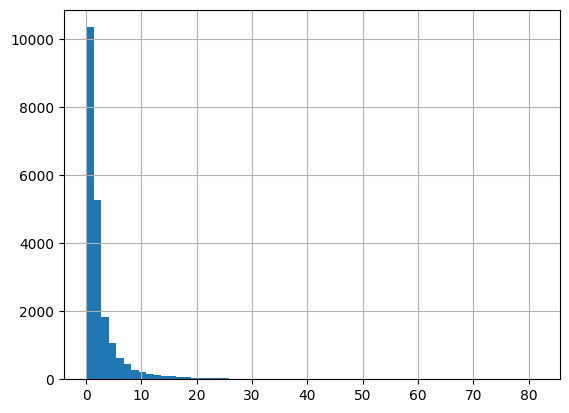

In [12]:
pairs["mahalanobis_dm"].hist(bins=60)

In [13]:
pairs["chi2Pos_calculated"] = pairs["mahalanobis_dm"]**2
df = pairs.copy()

In [14]:
df.head()

,xmm_idx,gaia_idx,sep_arcsec,xmm_SRCID,SC_POSERR,gaia_Source,pair_id,mahalanobis_dm,dx,dy,sigma_x,sigma_y,dx_norm,dy_norm,chi2Pos_calculated
0,51194,16,5.488035,206553001010081,1.850257,2312642114242366976,206553001010081_2312642114242366976,2.966093,-0.587038,-5.456547,1.850257,1.850257,-0.317274,-2.949076,8.797710
1,51292,31,2.748552,206553001010047,1.746716,2312643591711104000,206553001010047_2312643591711104000,1.573553,-2.748033,0.053399,1.746717,1.746718,-1.573256,0.030571,2.476069
2,51266,73,0.702259,206553001010017,0.818454,2312645825094127104,206553001010017_2312645825094127104,0.858030,-0.193967,0.674940,0.818455,0.818455,-0.236991,0.824652,0.736215
3,51276,95,1.207033,206553001010010,0.792295,2312646894541542784,206553001010010_2312646894541542784,1.523465,-1.201674,0.113619,0.792295,0.792295,-1.516700,0.143405,2.320944
4,51220,116,0.758145,206553001010009,0.750489,2312647955397902464,206553001010009_2312647955397902464,1.010200,-0.727426,0.213626,0.750491,0.750490,-0.969267,0.284649,1.020503


                mahalanobis_dm  sep_arcsec  SC_POSERR
mahalanobis_dm        1.000000    0.585745  -0.195419
sep_arcsec            0.585745    1.000000   0.346254
SC_POSERR            -0.195419    0.346254   1.000000


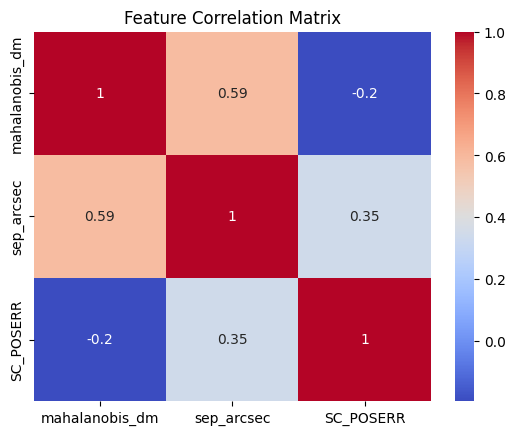

In [15]:
features = df[[
    "mahalanobis_dm",
    "sep_arcsec",
    "SC_POSERR"
]]
corr = features.corr()
print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
arches_df.head(1)

,dMEC,posRA,posDec,ePosA,ePosB,ePosPA,ePosEpoch,chi2Pos,proba_xg,proba_x_g,nPos,xmm_REVOLUT,xmm_OBS_ID_1,xmm_ODF_VERS_1,xmm_RA,xmm_DEC,xmm_PA_PNT_1,xmm_TARGET_1,xmm_MJD_START,xmm_MJD_STOP,xmm_OBS_CLASS,xmm_NDET_1,xmm_NDETGOOD_1,xmm_PN_NEXP_1,xmm_PN_FILT_1,xmm_PN_MODE_1,xmm_PN_TEXP_1,xmm_M1_NEXP_1,xmm_M1_FILT_1,xmm_M1_MODE_1,xmm_M1_TEXP_1,xmm_M2_NEXP_1,xmm_M2_FILT_1,xmm_M2_MODE_1,xmm_M2_TEXP_1,xmm_GAL_LONG_1,xmm_GAL_LAT_1,xmm_frac_1,xmm_gaia_count,xmm_No/Nx,xmm_Clusters,xmm_DETID,xmm_SRCID,xmm_DR3SRCID,xmm_DR3DETID,xmm_DR3DETDIST,xmm_DR3SRCDIST,xmm_DR3MULT,xmm_DR4SRCID,xmm_DR4DETID,xmm_DR4DETDIST,xmm_DR4SRCDIST,xmm_DR4MULT,xmm_IAUNAME,xmm_SRC_NUM,xmm_OBS_ID_2,xmm_REVOLUT_1,xmm_MJD_START_1,xmm_MJD_STOP_1,xmm_OBS_CLASS_1,xmm_PN_FILTER,xmm_M1_FILTER,xmm_M2_FILTER,xmm_PN_SUBMODE,xmm_M1_SUBMODE,xmm_M2_SUBMODE,xmm_RA_1,xmm_DEC_1,xmm_POSERR,xmm_LII,xmm_BII,xmm_RADEC_ERR,xmm_SYSERRCC,xmm_REFCAT,xmm_POSCOROK,xmm_RA_UNC,xmm_DEC_UNC,xmm_CCDPN,xmm_PN_RAWX,xmm_PN_RAWY,xmm_CCDM1,xmm_M1_RAWX,xmm_M1_RAWY,xmm_CCDM2,xmm_M2_RAWX,xmm_M2_RAWY,xmm_EP_1_FLUX,xmm_EP_1_FLUX_ERR,xmm_EP_2_FLUX,xmm_EP_2_FLUX_ERR,xmm_EP_3_FLUX,xmm_EP_3_FLUX_ERR,xmm_EP_4_FLUX,xmm_EP_4_FLUX_ERR,xmm_EP_5_FLUX,xmm_EP_5_FLUX_ERR,xmm_EP_8_FLUX,xmm_EP_8_FLUX_ERR,xmm_EP_9_FLUX,xmm_EP_9_FLUX_ERR,xmm_PN_1_FLUX,xmm_PN_1_FLUX_ERR,xmm_PN_2_FLUX,xmm_PN_2_FLUX_ERR,xmm_PN_3_FLUX,xmm_PN_3_FLUX_ERR,xmm_PN_4_FLUX,xmm_PN_4_FLUX_ERR,xmm_PN_5_FLUX,xmm_PN_5_FLUX_ERR,xmm_PN_8_FLUX,xmm_PN_8_FLUX_ERR,xmm_PN_9_FLUX,xmm_PN_9_FLUX_ERR,xmm_EP_8_RATE,xmm_EP_8_RATE_ERR,xmm_EP_9_RATE,xmm_EP_9_RATE_ERR,xmm_PN_1_RATE,xmm_PN_1_RATE_ERR,xmm_PN_2_RATE,xmm_PN_2_RATE_ERR,xmm_PN_3_RATE,xmm_PN_3_RATE_ERR,xmm_PN_4_RATE,xmm_PN_4_RATE_ERR,xmm_PN_5_RATE,xmm_PN_5_RATE_ERR,xmm_PN_8_RATE,xmm_PN_8_RATE_ERR,xmm_PN_9_RATE,xmm_PN_9_RATE_ERR,xmm_EP_8_CTS,xmm_EP_8_CTS_ERR,xmm_PN_8_CTS,xmm_PN_8_CTS_ERR,xmm_M1_8_CTS,xmm_M1_8_CTS_ERR,xmm_M2_8_CTS,xmm_M2_8_CTS_ERR,xmm_EP_8_DET_ML,xmm_EP_9_DET_ML,xmm_PN_1_DET_ML,xmm_PN_2_DET_ML,xmm_PN_3_DET_ML,xmm_PN_4_DET_ML,xmm_PN_5_DET_ML,xmm_PN_8_DET_ML,xmm_PN_9_DET_ML,xmm_EP_EXTENT,xmm_EP_EXTENT_ERR,xmm_EP_EXTENT_ML,xmm_EP_HR1,xmm_EP_HR1_ERR,xmm_EP_HR2,xmm_EP_HR2_ERR,xmm_EP_HR3,xmm_EP_HR3_ERR,xmm_EP_HR4,xmm_EP_HR4_ERR,xmm_PN_HR1,xmm_PN_HR1_ERR,xmm_PN_HR2,xmm_PN_HR2_ERR,xmm_PN_HR3,xmm_PN_HR3_ERR,xmm_PN_HR4,xmm_PN_HR4_ERR,xmm_PN_1_EXP,xmm_PN_2_EXP,xmm_PN_3_EXP,xmm_PN_4_EXP,xmm_PN_5_EXP,xmm_PN_1_BG,xmm_PN_2_BG,xmm_PN_3_BG,xmm_PN_4_BG,xmm_PN_5_BG,xmm_PN_PILEUP,xmm_M1_PILEUP,xmm_M2_PILEUP,xmm_PN_1_VIG,xmm_PN_2_VIG,xmm_PN_3_VIG,xmm_PN_4_VIG,xmm_PN_5_VIG,xmm_PN_ONTIME,xmm_M1_ONTIME,xmm_M2_ONTIME,xmm_EP_ONTIME,xmm_PN_OFFAX,xmm_M1_OFFAX,xmm_M2_OFFAX,xmm_EP_OFFAX,xmm_PN_MASKFRAC,xmm_M1_MASKFRAC,xmm_M2_MASKFRAC,xmm_DIST_NN,xmm_SUM_FLAG,xmm_EP_FLAG,xmm_PN_FLAG,xmm_M1_FLAG,xmm_M2_FLAG,xmm_TSERIES,xmm_SPECTRA,xmm_EP_CHI2PROB,xmm_PN_CHI2PROB,xmm_M1_CHI2PROB,xmm_M2_CHI2PROB,xmm_PN_FVAR,xmm_PN_FVARERR,xmm_M1_FVAR,xmm_M1_FVARERR,xmm_M2_FVAR,xmm_M2_FVARERR,xmm_VAR_FLAG,xmm_VAR_EXP_ID,xmm_VAR_INST_ID,xmm_SC_RA,xmm_SC_DEC,xmm_SC_POSERR,xmm_SC_DET_ML,xmm_SC_EP_1_FLUX,xmm_SC_EP_1_FLUX_ERR,xmm_SC_EP_2_FLUX,xmm_SC_EP_2_FLUX_ERR,xmm_SC_EP_3_FLUX,xmm_SC_EP_3_FLUX_ERR,xmm_SC_EP_4_FLUX,xmm_SC_EP_4_FLUX_ERR,xmm_SC_EP_5_FLUX,xmm_SC_EP_5_FLUX_ERR,xmm_SC_EP_8_FLUX,xmm_SC_EP_8_FLUX_ERR,xmm_SC_EP_9_FLUX,xmm_SC_EP_9_FLUX_ERR,xmm_SC_HR1,xmm_SC_HR1_ERR,xmm_SC_HR2,xmm_SC_HR2_ERR,xmm_SC_HR3,xmm_SC_HR3_ERR,xmm_SC_HR4,xmm_SC_HR4_ERR,xmm_SC_EXTENT,xmm_SC_EXT_ERR,xmm_SC_EXT_ML,xmm_SC_CHI2PROB,xmm_SC_FVAR,xmm_SC_FVARERR,xmm_SC_VAR_FLAG,xmm_SC_SUM_FLAG,xmm_SC_EP_8_FMIN,xmm_SC_EP_8_FMIN_ERR,xmm_SC_EP_8_FMAX,xmm_SC_EP_8_FMAX_ERR,xmm_MJD_FIRST,xmm_MJD_LAST,xmm_N_DETECTIONS,xmm_CONFUSED,xmm_HIGH_BACKGROUND,xmm_ODF_VERS_2,xmm_PA_PNT_2,xmm_TARGET_2,xmm_NDET_2,xmm_NDETGOOD_2,xmm_PN_NEXP_2,xmm_PN_FILT_2,xmm_PN_MODE_2,xmm_PN_TEXP_2,xmm_M1_NEXP_2,xmm_M1_FILT_2,xmm_M1_MODE_2,xmm_M1_TEXP_2,xmm_M2_NEXP_2,xmm_M2_FILT_2,xmm_M2_MODE_2,xmm_M2_TEXP_2,xmm_GAL_LONG_2,xmm_GAL_LAT_2,xmm_frac_2,xmm_GroupID,xmm_GroupSize,gaia_Source,gaia_DR3Name,gaia_RA_ICRS,gai

### Ground Truth Prep

In [17]:
arches_df["pair_id"] = (
    arches_df["xmm_SRCID"].astype(str) + "_" +
    arches_df["gaia_Source"].astype(str)
)

pairs["label"] = pairs["pair_id"].isin(arches_df["pair_id"]).astype(int)
pairs["label"].value_counts()
# pairs.groupby("xmm_idx")["label"].sum().value_counts()

label
1    14954
0     6043
Name: count, dtype: int64

In [18]:
pairs["xmm_idx"].nunique()
pairs.groupby("xmm_idx")["label"].sum().describe()

count    18802.000000
mean         0.795341
std          0.453841
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: label, dtype: float64

In [19]:
len(set(pairs["pair_id"]) & set(arches_df["pair_id"]))

14954

In [20]:
features = [
    "dx_norm",
    "dy_norm",
    "mahalanobis_dm",
    "sep_arcsec",
    "SC_POSERR"
]

X = pairs[features].values
y = pairs["label"].values
groups = pairs["xmm_idx"].values

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300)

In [22]:
pairs["pred_prob"] = model.predict_proba(X)[:,1]

In [23]:
best_matches = pairs.loc[
    pairs.groupby("xmm_idx")["pred_prob"].idxmax()
]

In [24]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, pairs["pred_prob"])
best_matches["correct"] = best_matches["label"]

accuracy = best_matches["correct"].mean()
print("Counterpart recovery accuracy:", accuracy)

Counterpart recovery accuracy: 0.774970747792788


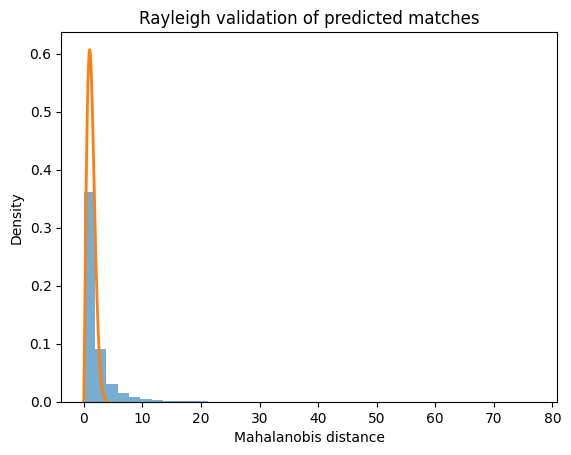

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

dm = best_matches["mahalanobis_dm"]

x = np.linspace(0,4,200)

plt.hist(dm, bins=40, density=True, alpha=0.6)
plt.plot(x, rayleigh.pdf(x), linewidth=2)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Rayleigh validation of predicted matches")
plt.show()

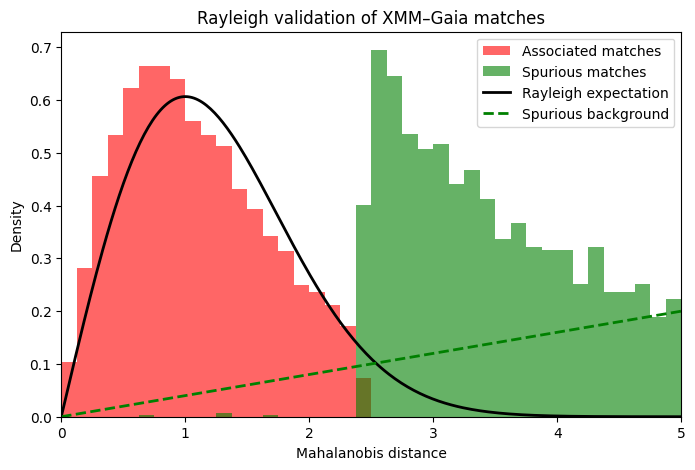

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# split matches
associated = best_matches[best_matches["label"] == 1]["mahalanobis_dm"]
spurious = best_matches[best_matches["label"] == 0]["mahalanobis_dm"]

# axis range
xmin = 0
xmax = 5   # change to 15 if desired

x = np.linspace(xmin, xmax, 300)

plt.figure(figsize=(8,5))

# histograms
plt.hist(associated, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="red",
         label="Associated matches")

plt.hist(spurious, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="green",
         label="Spurious matches")

# Rayleigh curve (true positional matches)
plt.plot(x, rayleigh.pdf(x, scale=1),
         color="black", linewidth=2,
         label="Rayleigh expectation")

# Poisson-like background approximation
# random matches scale roughly ∝ r in radial space
background = x / xmax**2
plt.plot(x, background,
         linestyle="--",
         color="green",
         linewidth=2,
         label="Spurious background")

plt.xlim(xmin, xmax)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Rayleigh validation of XMM–Gaia matches")
plt.legend()

plt.show()

Rayleigh sigma estimate: 0.8692246265220854


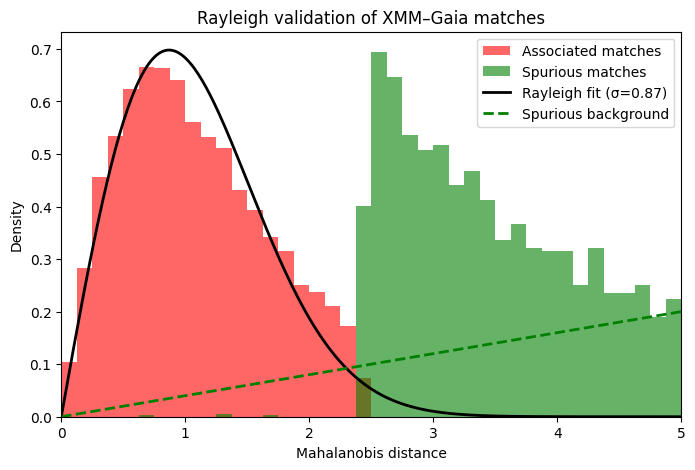

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# split matches
associated = best_matches[best_matches["label"] == 1]["mahalanobis_dm"]
spurious = best_matches[best_matches["label"] == 0]["mahalanobis_dm"]

# axis range
xmin = 0
xmax = 5
x = np.linspace(xmin, xmax, 300)

# --- Rayleigh scale estimation ---
sigma = np.sqrt((associated**2).mean() / 2)
rayleigh_fit = rayleigh.pdf(x, scale=sigma)

plt.figure(figsize=(8,5))

# histograms
plt.hist(associated, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="red",
         label="Associated matches")

plt.hist(spurious, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="green",
         label="Spurious matches")

# fitted Rayleigh curve
plt.plot(x, rayleigh_fit,
         color="black",
         linewidth=2,
         label=f"Rayleigh fit (σ={sigma:.2f})")

# spurious background
background = x / xmax**2
plt.plot(x, background,
         linestyle="--",
         color="green",
         linewidth=2,
         label="Spurious background")

plt.xlim(xmin, xmax)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Rayleigh validation of XMM–Gaia matches")
plt.legend()

print("Rayleigh sigma estimate:", sigma)

plt.show()